In [9]:

import numpy as np
import pandas as pd
import xarray as xr
from tqdm.notebook import tqdm
import gcsfs
import dask.bag as db
from dask.distributed import LocalCluster, Client
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xesmf as xe

In [2]:
cluster = LocalCluster(n_workers=16, threads_per_worker=2, memory_limit='8GiB')
client = Client(cluster)
client


/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40863 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:40863/status,
Dashboard: http://127.0.0.1:40863/status,Workers: 16
Total threads: 32,Total memory: 128.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44451,Workers: 0
Dashboard: http://127.0.0.1:40863/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44359,Total threads: 2
Dashboard: http://127.0.0.1:38667/status,Memory: 8.00 GiB
Nanny: tcp://127.0.0.1:39225,


In [3]:

fs = gcsfs.GCSFileSystem(token='anon')

all_days = pd.date_range('1979-01-01', '2024-12-31', freq='D')

gcs_root_pressure = 'gcp-public-data-arco-era5/raw/date-variable-pressure_level'
gcs_root_single   = 'gcp-public-data-arco-era5/raw/date-variable-single_level'

# ARCO canonical variable names in the path
cloud_stored_names = dict(
    u='u_component_of_wind', v='v_component_of_wind', t='temperature', pv='potential_vorticity',
    z='geopotential', msl='mean_sea_level_pressure',
    cape='convective_available_potential_energy', tcwv='total_column_water_vapour',
    q='specific_humidity', w='vertical_velocity',
)

chunks = {'time': 256, 'x': 64, 'y': 64}  # ~year per chunk; 1° NH: 91×360

from zarr.codecs import BloscCodec
compressor = BloscCodec(cname="zstd", clevel=3, shuffle="shuffle")


In [ ]:

# ── Configuration ────────────────────────────────────────────────────────────
zarr_out   = '/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/ERA5_daily_africa_newproject_raw.zarr'

LAT        = slice(0, 30)    # 0–30°N
LON        = slice(-60, 60)  # 60°W–60°E

TIME_CHUNK = 365             # ~1 year per time chunk

chunks = {'time': 256, 'y': 64, 'x': 64}


In [11]:

# -----------------------
# Helpers
# -----------------------
def url_for(day, variable, level):
    root = gcs_root_single if level == 'surface' else gcs_root_pressure
    canon = cloud_stored_names[variable]
    return f"{root}/{day.year:04d}/{day.month:02d}/{day.day:02d}/{canon}/{level}.nc"

def open_sample_ds(day, variable, level):
    url = url_for(day, variable, level)
    with fs.open(url) as f:
        return xr.open_dataset(f)  # metadata only; no chunks yet

def get_daily_data(day, variable, level, regridder):
    url = url_for(day, variable, level)
    with fs.open(url) as f:
        with xr.open_dataset(f) as ds:
            ds_var = ds[variable]
            mean_ds_new_grid = regridder(ds_var.mean('time'), keep_attrs=True)
            mean_ds_new_grid = mean_ds_new_grid.assign_coords(time=day).rename(variable).astype(np.float32)
            return mean_ds_new_grid

def get_sample_data(day, variable, level):
    url = url_for(day, variable, level)
    with fs.open(url) as f:
        with xr.open_dataset(f) as ds:
            ds_var = ds[variable]
            return ds_var.rename(variable).astype(np.float32).isel(time=0, drop=True)


def get_data_batch(day_index_start, day_index_end, variable, level, regridder):
    chunks = {'time': 256, 'y': 64, 'x': 64}
    days = all_days[day_index_start:day_index_end]
    if days.size == 0:
        return
    days_in_year = db.from_sequence(days)
    def open_daily_variable(d):
        return get_daily_data(d, variable, level, regridder)
    daily = days_in_year.map(open_daily_variable)
    da = xr.concat(daily, dim='time').chunk(chunks)
    return da

def write_variable_year(variable, level, day_index_start, day_index_end, regridder, mode='a'):
    da = get_data_batch(day_index_start, day_index_end, variable, level, regridder)
    var_name = variable if level == 'surface' else f"{variable}{level}"
    da = da.rename(var_name)
    if mode == 'w':
        enc = {var_name: {"compressor": compressor, "dtype": "float32", "chunks": (chunks['time'], chunks['longitude'], chunks['latitude'])},
               "longitude": {"compressor": compressor}, "latitude": {"compressor": compressor}, "time": {"compressor": compressor}}
    elif mode == 'a':
        enc = dict()
    ds = da.to_dataset()
    ds.to_zarr(zarr_out, mode=('w' if mode == 'w' else 'a'),
               append_dim=('time' if mode == 'a' else None), encoding=enc)

def overwrite_variable_year(variable, level, day_index_start, day_index_end, regridder, mode='a'):
    da = get_data_batch(day_index_start, day_index_end, variable, level, regridder)
    var_name = variable if level == 'surface' else f"{variable}{level}"
    da = da.rename(var_name)
    enc = dict()
    ds = da.to_dataset()#.drop_vars(['longitude', 'latitude', 'time'])
    ds.to_zarr(zarr_out, mode='a',
               region={"time": slice(day_index_start, day_index_end),
                       "longitude": slice(0, 256), "latitude": slice(0, 256)},
               encoding=enc)


<xarray.Dataset> Size: 199MB
Dimensions:    (time: 24, latitude: 721, longitude: 1440)
Coordinates:
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * time       (time) datetime64[ns] 192B 2000-07-01 ... 2000-07-01T23:00:00
Data variables:
    u          (time, latitude, longitude) float64 199MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2022-04-11 03:25:03 GMT by grib_to_netcdf-2.24.3: /opt/ecmw...
gcp-public-data-arco-era5/raw/date-variable-pressure_level/2000/07/01/u_component_of_wind/850.nc
gcp-public-data-arco-era5/raw/date-variable-single_level/2000/07/01/mean_sea_level_pressure/surface.nc
<xarray.DataArray 'u' (latitude: 721, longitude: 1440)> Size: 4MB
array([[ 7.9274568e-04,  7.9274568e-04,  7.9274568e-04, ...,
         7.9274568e-04,  7.9274568e-04,  7.9274568e-04],
       [ 1.4562547e+01,  1.4548341e+01,  1.4536977e+01, ...,
         1.4598060e+01,  1.

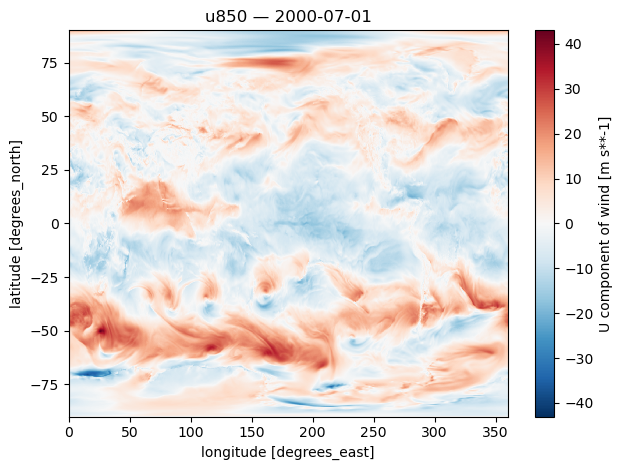

In [8]:

# ── Smoke test: inspect a single day ─────────────────────────────────────────
sample_day = pd.Timestamp('2000-07-01')
ds_sample = open_sample_ds(sample_day, 'u', 850)
print(ds_sample)

# Check URL construction
print(url_for(sample_day, 'u', 850))
print(url_for(sample_day, 'msl', 'surface'))

# Load one day without regridding
da_sample = get_sample_data(sample_day, 'u', 850)
print(da_sample)
da_sample.plot()
plt.title(f"u850 — {sample_day.date()}")
plt.tight_layout()


In [12]:

# ── Main write loop ───────────────────────────────────────────────────────────
# Variables: (short_name, level)  — level='surface' for single-level fields
variables_levels = [
    ('u',    700), ('u',    850),
    ('v',    700), ('v',    850),
    ('z',    700), ('z',    850),
    ('q',    700), ('q',    850),
    ('t',    700), ('t',    850),
    ('w',    500),
    ('msl',  'surface'),
    ('tcwv', 'surface'),
]

# Define regridder before running — example using xe.Regridder:
# ds_sample = open_sample_ds(all_days[0], 'u', 850)
# ds_out_grid = xr.Dataset({'lat': (['lat'], np.arange(LAT.start, LAT.stop+1)),
#                            'lon': (['lon'], np.arange(LON.start, LON.stop+1))})
# regridder = xe.Regridder(ds_sample, ds_out_grid, 'bilinear')

sample_data = get_sample_data(pd.to_datetime('2005-11-14'), variable='msl', level='surface')
target_grid = xr.Dataset({'latitude': (['latitude'], np.arange(0, 30.1,.5)),
                          'longitude': (['longitude'], np.arange(-60,60.1,.5))})
regridder = xe.Regridder(sample_data, target_grid, method='bilinear',periodic=True)

for i, (variable, level) in enumerate(tqdm(variables_levels, desc='Variables')):
    mode = 'w' if i == 0 else 'a'
    write_variable_year(variable, level, 0, len(all_days), regridder, mode=mode)

print(f'Done!  →  {zarr_out}')


Variables:   0%|          | 0/13 [00:00<?, ?it/s]

ValueError: chunks keys ('x', 'y') not found in data dimensions ('latitude', 'longitude', 'time')

In [5]:
# ── Verify output ─────────────────────────────────────────────────────────────
ds_out = xr.open_zarr(OUT_PATH, consolidated=True)
print(ds_out)
print(f"\nTime range : {ds_out.time.values[0]}  →  {ds_out.time.values[-1]}")
print(f"Grid       : lat {ds_out.latitude.values[[0,-1]]}  lon {ds_out.longitude.values[[0,-1]]}")


ValueError: .zmetadata

In [ ]:
# ── Quick visual check of a sample timestep ──────────────────────────────────
ds_out = xr.open_zarr(OUT_PATH, consolidated=True)
ds_out.isel(time=200).to_array('var_name').plot(
    col='var_name', col_wrap=4,
    subplot_kws={'projection': ccrs.PlateCarree()},
    transform=ccrs.PlateCarree()
)
plt.gcf().set_size_inches(22, 10)
for ax in plt.gcf().axes:
    if hasattr(ax, 'coastlines'):
        ax.coastlines()
plt.tight_layout()


/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 39.76 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [ ]:
# normalised climatology check (optional)
ds_clim = ds_out.mean('time').compute()
((ds_out.isel(time=200).compute() - ds_clim) / ds_out.std('time').compute()).to_array('var_name').plot(
    col='var_name', col_wrap=4, vmin=-3, vmax=3,
    subplot_kws={'projection': ccrs.PlateCarree()},
    transform=ccrs.PlateCarree()
)
plt.gcf().set_size_inches(22, 10)
for ax in plt.gcf().axes:
    if hasattr(ax, 'coastlines'):
        ax.coastlines()
plt.tight_layout()


In [36]:
# Dataset size on disk
ds_out = xr.open_zarr(OUT_PATH, consolidated=True)
print(f"Total output size: {ds_out.nbytes / 1e9:.2f} GB (uncompressed in-memory estimate)")
ds_out


24.122581608

/tmp/ipykernel_3066864/4271003356.py:3: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax in plot.axes.flat:


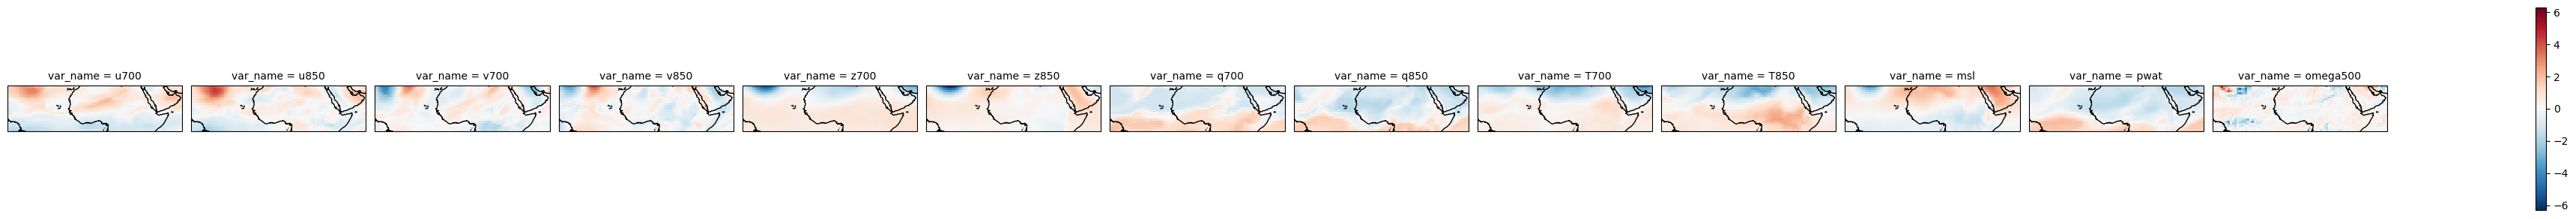

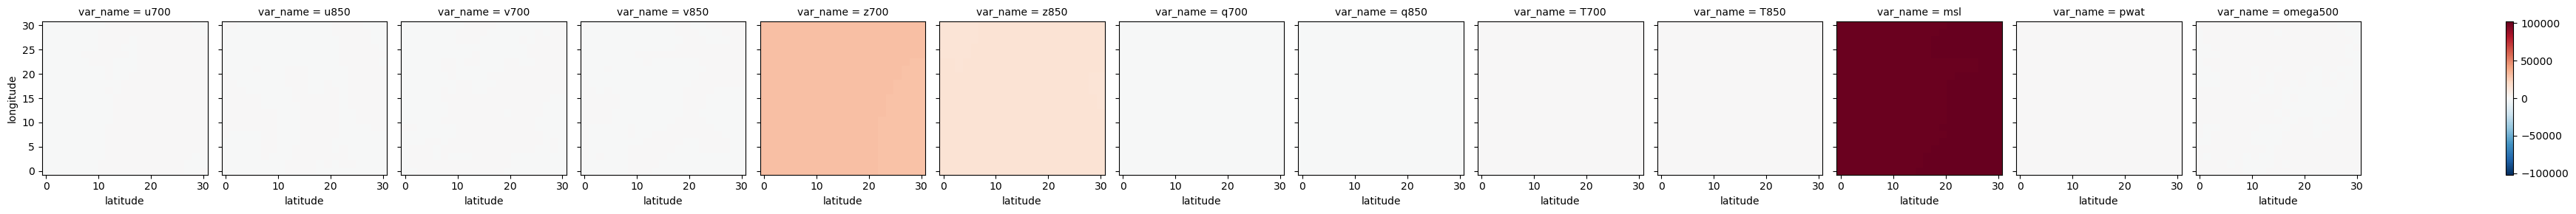